In [55]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

/kaggle/input/datasets/chaitanyazunzurkar/fashion-mnist/fashion-mnist_test.csv
/kaggle/input/datasets/chaitanyazunzurkar/fashion-mnist/fashion-mnist_train.csv
2.10.0+cu128
12.8
True
Tesla T4


In [56]:
train = pd.read_csv('/kaggle/input/datasets/chaitanyazunzurkar/fashion-mnist/fashion-mnist_train.csv')
test = pd.read_csv('/kaggle/input/datasets/chaitanyazunzurkar/fashion-mnist/fashion-mnist_test.csv')

In [57]:
train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [58]:
test.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [59]:
X_train = train.iloc[:, 1:].values
y_train = train.iloc[:, 0].values

X_test = test.iloc[:, 1:].values
y_test = test.iloc[:, 0].values

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

X_train_tensor, X_val_tensor, y_train_tensor, y_val_tensor = train_test_split(
    X_train_tensor,
    y_train_tensor,
    test_size=0.2,
    random_state=42
)

In [60]:
class CustomDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.X)

  def __getitem__(self, index):
    return self.X[index], self.y[index]

In [61]:
train_dataset = CustomDataset(X_train_tensor, y_train_tensor)
val_dataset = CustomDataset(X_val_tensor, y_val_tensor)
test_dataset = CustomDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [62]:
class Model(nn.Module):
  def __init__(self, features):
    super().__init__()
    self.features = features

    self.network = nn.Sequential(
        nn.Linear(self.features, 128),
        nn.ReLU(),
        nn.BatchNorm1d(128),
        nn.Dropout(0.3),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.BatchNorm1d(64),
        nn.Dropout(0.2),
        nn.Linear(64, 10)
    )

  def forward(self, X):
    return self.network(X)

In [63]:
loss_function = nn.CrossEntropyLoss()

learning_rate = 0.001
epochs = 100

model = Model(X_train_tensor.shape[1])
model = model.to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate,
    weight_decay=1e-4
)

In [64]:
best_loss = float('inf')
patience = 10
counter = 0

In [65]:
train_loss_history = []
val_loss_history = []

train_acc_history = []
val_acc_history = []

In [66]:
for epoch in range(epochs): 
    
    model.train() 
    train_loss = 0 
    train_correct = 0
    train_total = 0
    
    for X_batch, y_batch in train_loader: 
        
        X_batch = X_batch.float().to(device)
        y_batch = y_batch.to(device)
    
        y_pred = model(X_batch) 

        prediction = torch.argmax(
            y_pred,
            dim=1
        )

        train_correct += (y_batch == prediction).sum().item()

        train_total += y_batch.size(0)
        
        loss = loss_function(y_pred, y_batch)
    
        optimizer.zero_grad()
    
        loss.backward() 
    
        optimizer.step() 
    
        train_loss += loss.item() 


    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        
        for X_batch, y_batch in val_loader:
            
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            predictions = torch.argmax(
                y_pred,
                dim=1
            )
            
            val_correct += (
                predictions == y_batch
            ).sum().item()
            
            val_total += y_batch.size(0)
            loss = loss_function(y_pred, y_batch)

            val_loss += loss.item()


    train_loss = train_loss / len(train_loader)
    train_accuracy  = (train_correct / train_total)
    
    val_loss = val_loss / len(val_loader)
    val_accuracy = (val_correct / val_total)

    train_loss_history.append(
        train_loss
    )
    
    val_loss_history.append(
        val_loss
    )
    
    train_acc_history.append(
        train_accuracy
    )
    
    val_acc_history.append(
        val_accuracy
    )
        
    print(
        f'Epoch {epoch+1} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Val Loss: {val_loss:.4f} | '
        f'Train Acc: {train_accuracy:.4f} | '
        f'Val Acc: {val_accuracy:.4f}'
    )

    if val_loss < best_loss: 
        best_loss = val_loss
        counter = 0

        torch.save(
            model.state_dict(),
            'best_model.pth'
        )
    else:
        counter += 1
        
        if counter >= patience: 
            print("\nEarly Stopping")
            break 

Epoch 1 | Train Loss: 0.6062 | Val Loss: 0.4364 | Train Acc: 0.7976 | Val Acc: 0.8421
Epoch 2 | Train Loss: 0.4550 | Val Loss: 0.4126 | Train Acc: 0.8385 | Val Acc: 0.8508
Epoch 3 | Train Loss: 0.4260 | Val Loss: 0.3685 | Train Acc: 0.8484 | Val Acc: 0.8675
Epoch 4 | Train Loss: 0.4019 | Val Loss: 0.3689 | Train Acc: 0.8536 | Val Acc: 0.8609
Epoch 5 | Train Loss: 0.3938 | Val Loss: 0.3510 | Train Acc: 0.8589 | Val Acc: 0.8712
Epoch 6 | Train Loss: 0.3796 | Val Loss: 0.3603 | Train Acc: 0.8642 | Val Acc: 0.8658
Epoch 7 | Train Loss: 0.3780 | Val Loss: 0.3653 | Train Acc: 0.8641 | Val Acc: 0.8611
Epoch 8 | Train Loss: 0.3644 | Val Loss: 0.3488 | Train Acc: 0.8680 | Val Acc: 0.8715
Epoch 9 | Train Loss: 0.3661 | Val Loss: 0.3385 | Train Acc: 0.8666 | Val Acc: 0.8746
Epoch 10 | Train Loss: 0.3597 | Val Loss: 0.3286 | Train Acc: 0.8711 | Val Acc: 0.8778
Epoch 11 | Train Loss: 0.3518 | Val Loss: 0.3280 | Train Acc: 0.8722 | Val Acc: 0.8787
Epoch 12 | Train Loss: 0.3563 | Val Loss: 0.3390 | T

In [67]:
model.eval() 

correct = 0 
total = 0 

model.load_state_dict(
    torch.load(
        'best_model.pth'
    )
)

with torch.no_grad(): 
  for X_batch, y_batch in test_loader:
     
    X_batch = X_batch.float().to(device)
    y_batch = y_batch.to(device)

    y_pred = model(X_batch) 

    predictions = torch.argmax( y_pred, dim=1 ) 

    correct += ( predictions == y_batch ).sum().item() 

    total += y_batch.size(0) 
    
accuracy = ( correct / total ) 
print( f'\nAccuracy: {accuracy*100:.2f}%')


Accuracy: 88.53%


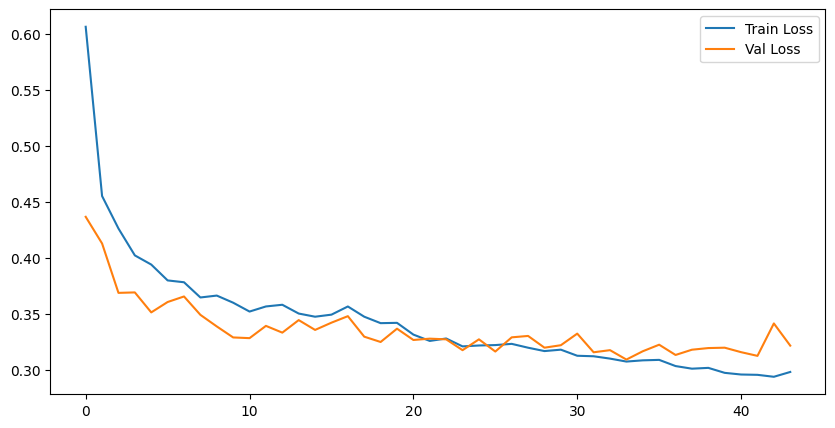

In [68]:
plt.figure(figsize=(10,5))

plt.plot(
    train_loss_history,
    label='Train Loss'
)

plt.plot(
    val_loss_history,
    label='Val Loss'
)

plt.legend()

plt.show()

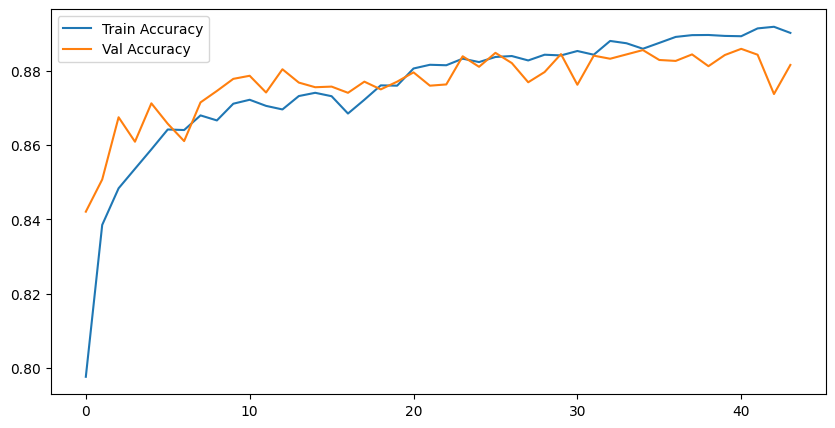

In [69]:
plt.figure(figsize=(10,5))

plt.plot(
    train_acc_history,
    label='Train Accuracy'
)

plt.plot(
    val_acc_history,
    label='Val Accuracy'
)

plt.legend()

plt.show()